In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.set_default_dtype(torch.float64)


In [ ]:
# Physical Parameters
E = 1.5e7     # kN/m2
NU = 1/6   
R = 10.0       # m
L = 20.0
h = 0.12    # m

gamma_c = 24
gamma_w = 10
p_x = -gamma_c * h

Cm = (E * h) / (1 - NU**2)

# Hyperparameters
epochs = 5000
lr = 0.001
num_interior = 50
num_boundary = 100


In [ ]:
# Non-dimensionalization
w0 = (gamma_w * L * R**2) / (Cm) 
u0 = (abs(p_x) * L**2) / (Cm)

Pi_0_ex = Cm * (u0 / L)**2
Pi_0_et = Cm * (w0 / R)**2
print('Pi_0_ex ', Pi_0_ex)
print('Pi_0_et ', Pi_0_et)
Pi_0 = max(Pi_0_ex, Pi_0_et)

# Some arrays
previous_loss = float('inf')
loss_history = []


Pi_0_u  0.0017919999999999995
Pi_0_w  2.1604938271604945


In [90]:
def grad(f, v):
    return torch.autograd.grad(f, v, grad_outputs=torch.ones_like(f), create_graph=True)[0]

In [91]:
# 1. Neural Network Architecture
class MembraneCylindricalPINN(nn.Module):
    def __init__(self, input_size, output_size, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, x):
        output = self.network(x)
        u_bar = x * output[:, 0:1]
        w_bar = output[:, 1:2]
        u = u_bar * u0
        w = w_bar * w0
        return u , w

In [92]:
# 2. Potential Energy and BC Loss Functions
def membrane(model, x_phys):
    x_phys.requires_grad_(True)
    x_bar = x_phys/L
    
    # Forward pass
    u, w = model(x_bar)
            
    # Kinematic Equations
    e_x = grad(u, x_phys)
    e_t = w / R

    # Constitutive Equations
    n_x = Cm * (e_x + NU * e_t)
    n_t = Cm * (e_t + NU * e_x)
    
    # Internal Energy
    U_mem = 0.5 * (n_x * e_x + n_t * e_t)

    # External Work
    p_n = gamma_w * (L - x_phys) 
    W_density = p_x * u + p_n * w

    # Total
    # Pi_0 = Cm * (w0 / R)**2
    loss_energy = torch.mean(U_mem - W_density) / Pi_0

    # BCs
    x_top = torch.tensor([[L]], dtype=torch.float64, device=x_phys.device, requires_grad=True)
    u_top, w_top = model(x_top / L)
    du_dx_top = grad(u_top, x_top)
    ex_top = du_dx_top
    et_top = w_top / R
    nx_top = ex_top + NU * et_top
    nt_top = et_top + NU * ex_top
    n_0 = w0 / L
    loss_nx_top = ((nx_top / n_0)**2).squeeze()
    loss_nt_top = ((nt_top / n_0)**2).squeeze()

    # Choose penalty of loss = 1.0
    # increasing this decreases the effect of loss_energy
    return loss_energy + 1.0*(loss_nx_top + loss_nt_top)


Boundary Gradient Bias: 
- Neural networks naturally struggle to capture the exact slope at the very edge of a domain compared to the center.
- At $x=0$, the displacement $u$ is forced to be $0$ by your boundary condition mask. In the energy functional $\int (U - W) dx$, the Work term for self-weight is $p_x \cdot u$. Since $u \approx 0$ near the base, the optimizer has very little "incentive" at $x=0$ to get the slope $du/dx$ exactly right. It only "learns" the value of $n_x$ at the base by looking at the weight of the entire shell above it.

-> Biased Sampling: Put more collocation points near $x=0$ to force the network to respect the stress state at the support.

In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MembraneCylindricalPINN(1, 2, 64).to(device)

# Training Loop
print("Starting training...")

# Generate Points
x_col = torch.linspace(0, L, 2000, device=device).unsqueeze(1)
# x_col = torch.cat([
#     torch.linspace(0, L, 1500, device=device).unsqueeze(1),
#     torch.linspace(0, 0.1*L, 400, device=device).unsqueeze(1)
# ], dim=0)

# --- PHASE 1: ADAM OPTIMIZER ---
optimizer_adam = optim.Adam(model.parameters(), lr=2e-3)
print("Phase 1: Adam Optimizer (Finding the neighborhood)")
for epoch in range(epochs+1):
    optimizer_adam.zero_grad()

    # Physics loss (Energy minimization)
    total_loss = membrane(model, x_col)

    total_loss.backward()
    optimizer_adam.step()
    
    current_loss = total_loss.item()
    loss_history.append(current_loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Energy: {current_loss}")
    
    # Convergence Check
    if epoch > 0:
        relative_error = abs(previous_loss - current_loss) / abs(current_loss + 1e-15)
        if relative_error < 1e-20:
            print(f"Convergent at epoch {epoch}. Relative error: {relative_error}")
            break
    
    previous_loss = current_loss    

# --- PHASE 2: L-BFGS OPTIMIZER ---
print("\nPhase 2: L-BFGS Optimizer (High-precision polishing)")
# L-BFGS requires a static set of points during its line search closure
# x_static = torch.cat([
#     torch.linspace(0, L, 4000, device=device).unsqueeze(1),
#     torch.tensor([[0.0], [L]], dtype=torch.float64, device=device)
# ], dim=0)
x_static = torch.linspace(0, L, 4000, device=device).unsqueeze(1)

optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                                max_iter=3000,
                                tolerance_grad=1e-7, 
                                tolerance_change=1e-9, 
                                history_size=100,
                                line_search_fn="strong_wolfe")

def closure():
    optimizer_lbfgs.zero_grad()
    loss = membrane(model, x_static)
    loss.backward()
    return loss
    
optimizer_lbfgs.step(closure)

# Print final loss after L-BFGS
final_loss = membrane(model, x_static)
print(f"  Final L-BFGS Energy Loss: {final_loss.item():.6e}\n")

Starting training...
Phase 1: Adam Optimizer (Finding the neighborhood)
Epoch 0 | Energy: 0.20461197840444736
Epoch 500 | Energy: -0.17319196524784355
Epoch 1000 | Energy: -0.1732276173480024
Epoch 1500 | Energy: -0.17322483725947302
Epoch 2000 | Energy: -0.173251173222328
Epoch 2500 | Energy: -0.17325185086797937
Epoch 3000 | Energy: -0.17325837783313724
Epoch 3500 | Energy: -0.1732575981015815
Epoch 4000 | Energy: -0.17325857398585273
Epoch 4500 | Energy: -0.1732582212157896
Epoch 5000 | Energy: -0.1732578551089319

Phase 2: L-BFGS Optimizer (High-precision polishing)
  Final L-BFGS Energy Loss: -1.732365e-01



In [94]:
device = next(model.parameters()).device
model.eval() # Set to evaluation mode

test_x = [0.0, L/2, L] 

print(f"\n==========================================================================================")
print(f"Results for Membrane State under Self-Weight and Hydrostatic Pressure")
print(f"==========================================================================================")
print(f"{'Height (x)':<12} | {'Quantity':<15} | {'PINN':<18} | {'Analytical':<18} | {'Error (%)'}")
print(f"------------------------------------------------------------------------------------------")

for x_val in test_x:
    x_t = torch.tensor([[x_val]], dtype=torch.float64, requires_grad=True)
    u, w = model(x_t / L)
        
    # Numerical Forces
    ex_num = float((grad(u, x_t)).item())
    et_num = float(w.item() / R)
    
    nx_num = Cm * (ex_num + NU * et_num)
    nt_num = Cm * (et_num + NU * ex_num)
    
    # Analytical Forces (Exact Membrane Solution)
    ex_exact = (-gamma_c*h - NU*gamma_w*R)*(L-x_val)/(E*h)
    et_exact = (gamma_w*R + NU*gamma_c*h)*(L-x_val)/(E*h)
    nx_exact = Cm * (ex_exact + NU * et_exact)
    nt_exact = Cm * (et_exact + NU * ex_exact)
    # nx_exact = p_x * (L - x_val)
    # nt_exact = gamma_w * R * (L - x_val)
    
    # Errors
    err_nx = abs((nx_num - nx_exact)/nx_exact)*100 if abs(nx_exact)>1e-7 else 0
    err_nt = abs((nt_num - nt_exact)/nt_exact)*100 if abs(nt_exact)>1e-7 else 0
    err_ex = abs((ex_num - ex_exact)/ex_exact)*100 if abs(ex_exact)>1e-7 else 0
    err_et = abs((et_num - et_exact)/et_exact)*100 if abs(et_exact)>1e-7 else 0
    
    print(f"{x_val:<12.2f} | {'e_x ':<15} | {ex_num:<18.4e} | {ex_exact:<18.4e} | {err_ex:.4f}%")
    print(f"{'':<12} | {'e_theta ':<15} | {et_num:<18.4e} | {et_exact:<18.4e} | {err_et:.4f}%")
    print(f"{'':<12} | {'n_x ':<15} | {nx_num:<18.4e} | {nx_exact:<18.4e} | {err_nx:.4f}%")
    print(f"{'':<12} | {'n_theta ':<15} | {nt_num:<18.4e} | {nt_exact:<18.4e} | {err_nt:.4f}%")
    print(f"------------------------------------------------------------------------------------------")


Results for Membrane State under Self-Weight and Hydrostatic Pressure
Height (x)   | Quantity        | PINN               | Analytical         | Error (%)
------------------------------------------------------------------------------------------
0.00         | e_x             | -2.1524e-04        | -2.1719e-04        | 0.8977%
             | e_theta         | 1.1089e-03         | 1.1164e-03         | 0.6773%
             | n_x             | -5.6323e+01        | -5.7600e+01        | 2.2164%
             | n_theta         | 1.9866e+03         | 2.0000e+03         | 0.6699%
------------------------------------------------------------------------------------------
10.00        | e_x             | -1.0881e-04        | -1.0859e-04        | 0.1972%
             | e_theta         | 5.5946e-04         | 5.5822e-04         | 0.2212%
             | n_x             | -2.8816e+01        | -2.8800e+01        | 0.0539%
             | n_theta         | 1.0022e+03         | 1.0000e+03         | 0.2220

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


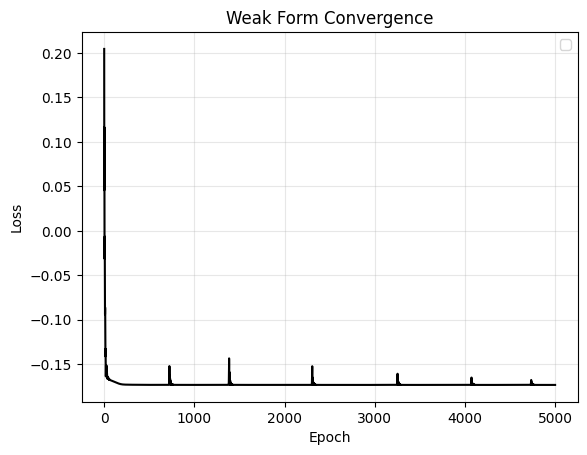

In [95]:
plt.plot(loss_history, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Weak Form Convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()